# Underwater Object Detection v2

**Primary model:** YOLOv9c on URPC 2019 (5 marine classes)  
**Optional baseline:** YOLO11s

### Setup (Kaggle)
1. Attach dataset: **`urpc2019-640-15pct`** ([create with `prepare_urpc640.py`](../prepare_urpc640.py))
2. Settings → **GPU T4 x2**, Internet **On**, Restart Session
3. Set `RUN_SMOKE_TEST = False` for full training (or `True` for 1-epoch CPU smoke test)
4. **Save Version** after run to download weights and predictions

**Kaggle notebook:** https://www.kaggle.com/code/salonichippa/underwater-yolo


In [1]:
!pip install -q ultralytics opencv-python-headless pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.7 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import glob
import gc
import yaml
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from ultralytics import YOLO

warnings.filterwarnings('ignore')
print('Ultralytics YOLO ready')
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics YOLO ready
CUDA available: True
GPU: Tesla T4


In [3]:
# Configuration

CLASSES = ['echinus', 'starfish', 'holothurian', 'scallop', 'waterweeds']

RUN_SMOKE_TEST = False   # True = CPU smoke test (1 epoch, 10% data)
RUN_BASELINE = True     # True = also train YOLO11s for comparison

IMGSZ = 640
SEED = 88

if RUN_SMOKE_TEST:
    PRIMARY_MODEL = 'yolov9c.pt'
    EPOCHS = 1
    BATCH_SIZE = 2
    FRACTION = 0.10
    DEVICE = 'cpu'
    RUN_NAME = 'smoke_yolov9c'
else:
    PRIMARY_MODEL = 'yolov9c.pt'
    EPOCHS = 80
    BATCH_SIZE = 4          # use 2 if OOM
    FRACTION = 1.0
    RUN_NAME = 'yolov9c_urpc640_15pct'
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError('Enable GPU T4 and Restart Session before full training.')
    DEVICE = 0

BASELINE_MODEL = 'yolo11s.pt'
BASELINE_RUN_NAME = 'yolo11s_urpc640_15pct_baseline'

OUTPUT_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else '.'
DATA_YAML = os.path.join(OUTPUT_DIR, 'data.yaml')

DATASET_DIR = '/kaggle/input/datasets/salonichippa/urpc2019-640-15pct'
if DATASET_DIR is None:
    raise FileNotFoundError('Attach urpc2019-640-15pct dataset via Add Data.')

print('Mode:', 'SMOKE TEST' if RUN_SMOKE_TEST else 'FULL TRAINING')
print('Dataset:', DATASET_DIR)
print('Model:', PRIMARY_MODEL, '| Epochs:', EPOCHS, '| Batch:', BATCH_SIZE, '| Device:', DEVICE)


Mode: FULL TRAINING
Dataset: /kaggle/input/datasets/salonichippa/urpc2019-640-15pct
Model: yolov9c.pt | Epochs: 80 | Batch: 4 | Device: 0


In [4]:
# Write data.yaml pointing to attached dataset
dataset_yaml = {
    'path': DATASET_DIR,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': len(CLASSES),
    'names': CLASSES,
}

with open(DATA_YAML, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print('data.yaml:')
print(open(DATA_YAML).read())

data.yaml:
path: /kaggle/input/datasets/salonichippa/urpc2019-640-15pct
train: train/images
val: val/images
test: test/images
nc: 5
names:
- echinus
- starfish
- holothurian
- scallop
- waterweeds



In [5]:
# Verify dataset structure and class distribution
def count_dataset(base_dir):
    rows = []
    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(base_dir, split, 'images')
        lbl_dir = os.path.join(base_dir, split, 'labels')
        n_img = len(os.listdir(img_dir)) if os.path.isdir(img_dir) else 0
        class_counts = {c: 0 for c in CLASSES}
        if os.path.isdir(lbl_dir):
            for lf in os.listdir(lbl_dir):
                with open(os.path.join(lbl_dir, lf)) as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            cid = int(float(parts[0]))
                            if 0 <= cid < len(CLASSES):
                                class_counts[CLASSES[cid]] += 1
        rows.append({'split': split, 'images': n_img, **class_counts})
    return pd.DataFrame(rows)

stats_df = count_dataset(DATASET_DIR)
display(stats_df)

# Sanity check: sample image size
sample = glob.glob(os.path.join(DATASET_DIR, 'train', 'images', '*'))[0]
with Image.open(sample) as im:
    print(f'Sample: {os.path.basename(sample)} → {im.size}')

,split,images,echinus,starfish,holothurian,scallop,waterweeds
0,train,506,0,2103,626,492,669
1,val,141,0,457,146,157,182
2,test,56,0,262,85,37,59


Sample: GOPR0293_18579.jpg → (640, 640)


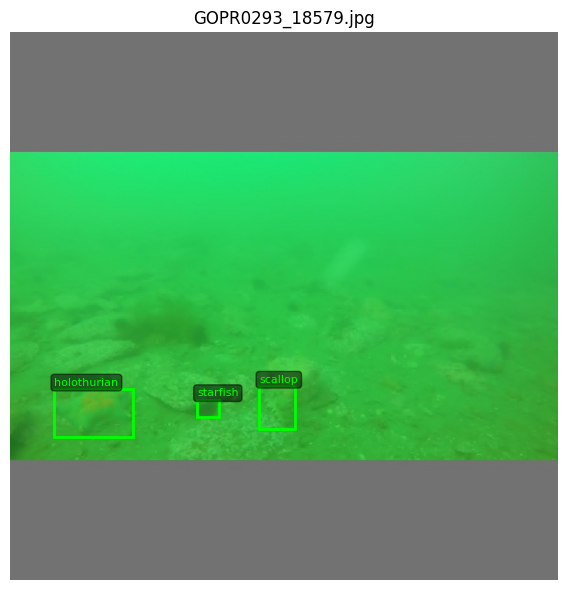

In [6]:
# Visualize one training image with labels
def plot_sample(img_path, lbl_path):
    img = np.array(Image.open(img_path))
    h, w = img.shape[:2]
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cid, xc, yc, bw, bh = parts
                cid = int(float(cid))
                xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                rect_w, rect_h = bw * w, bh * h
                ax.add_patch(plt.Rectangle((x1, y1), rect_w, rect_h,
                             fill=False, edgecolor='lime', linewidth=2))
                ax.text(x1, y1 - 4, CLASSES[cid], color='lime', fontsize=8,
                        bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    ax.set_title(os.path.basename(img_path))
    ax.axis('off')
    plt.tight_layout()
    plt.show()

s_img = glob.glob(os.path.join(DATASET_DIR, 'train', 'images', '*'))[0]
s_lbl = os.path.join(DATASET_DIR, 'train', 'labels', Path(s_img).stem + '.txt')
plot_sample(s_img, s_lbl)

In [7]:
%%time
# ── Train YOLOv9c (primary) ───────────────────────────────────────────────

model = YOLO(PRIMARY_MODEL)

results = model.train(
    data=DATA_YAML,
    task='detect',
    imgsz=IMGSZ,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    fraction=FRACTION,
    optimizer='AdamW',
    lr0=1e-4,
    lrf=0.01,
    cos_lr=True,                # NEW — smoother LR decay
    weight_decay=0.0005,
    patience=15,
    name=RUN_NAME,
    seed=SEED,
    device=DEVICE,
    amp=True,
    cache=False,
    workers=2,
    exist_ok=True,
    verbose=True,
    # Underwater-friendly augmentation
    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,
    mosaic=1.0,
    mixup=0.05,
    copy_paste=0.1,             # helps rare classes (scallop, echinus)
    close_mosaic=10,
)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('Training complete. Run name:', RUN_NAME)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9c_urpc640_15pct, nbs=64, nms=F

In [8]:
# ── Evaluate on test split ────────────────────────────────────────────────

best_weights = os.path.join('runs', 'detect', RUN_NAME, 'weights', 'best.pt')
assert os.path.exists(best_weights), f'Weights not found: {best_weights}'

best_model = YOLO(best_weights)
metrics = best_model.val(data=DATA_YAML, split='test', imgsz=IMGSZ, device=DEVICE)

print('\n=== Test metrics (YOLOv9c — 15% URPC) ===')
print(f'mAP@0.5:      {metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95: {metrics.box.map:.4f}')
print(f'Precision:    {metrics.box.mp:.4f}')
print(f'Recall:       {metrics.box.mr:.4f}')

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv9c summary (fused): 156 layers, 25,323,103 parameters, 0 gradients, 102.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.8±0.7 ms, read: 10.0±1.3 MB/s, size: 52.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/salonichippa/urpc2019-640-15pct/test/labels... 56 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 402.3it/s 0.1s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/salonichippa/urpc2019-640-15pct/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2it/s 3.3s1.3s
                   all         56        443      0.774      0.624      0.719      0.383
              starfish         47        262      0.896      0.793      0.902       0.

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
50,51,1676.59,1.20413,0.65672,1.08366,0.79365,0.70387,0.74515,0.38721,1.69302,1.06029,1.43925,0.000032,0.000032,0.000032
51,52,1709.48,1.17824,0.67339,1.07088,0.78662,0.71293,0.74679,0.38379,1.69095,1.03967,1.44507,0.000030,0.000030,0.000030
52,53,1742.29,1.18053,0.65867,1.07927,0.78222,0.73706,0.75776,0.38374,1.70641,1.05386,1.44759,0.000028,0.000028,0.000028
53,54,1775.23,1.19684,0.67461,1.08799,0.79115,0.71832,0.75805,0.39225,1.67975,1.04233,1.42985,0.000026,0.000026,0.000026
54,55,1808.12,1.19716,0.66171,1.06796,0.77620,0.72764,0.76338,0.39509,1.68483,1.02613,1.42850,0.000025,0.000025,0.000025


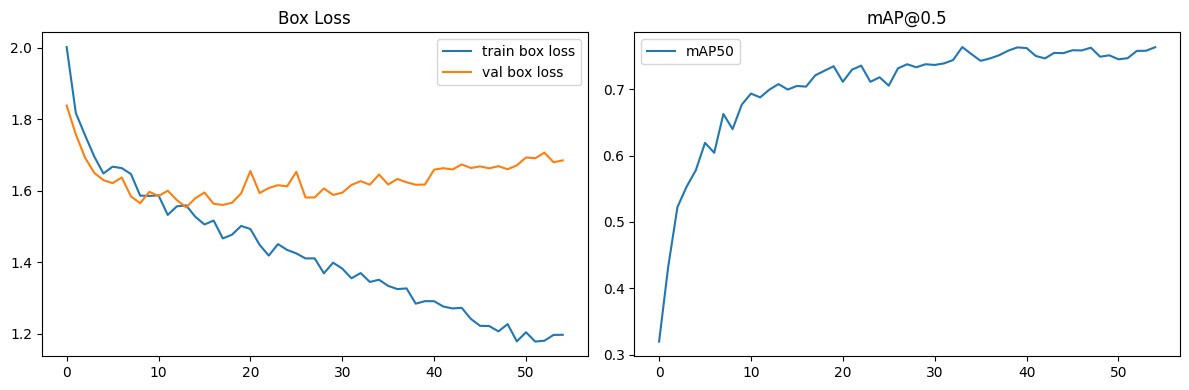

In [9]:
# Training curves
results_csv = os.path.join('runs', 'detect', RUN_NAME, 'results.csv')
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    display(df.tail())
    df.to_csv(os.path.join(OUTPUT_DIR, f'{RUN_NAME}_results.csv'), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if 'train/box_loss' in df.columns:
        axes[0].plot(df['train/box_loss'], label='train box loss')
        axes[0].plot(df['val/box_loss'], label='val box loss')
        axes[0].legend(); axes[0].set_title('Box Loss')
    if 'metrics/mAP50(B)' in df.columns:
        axes[1].plot(df['metrics/mAP50(B)'], label='mAP50')
        axes[1].legend(); axes[1].set_title('mAP@0.5')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{RUN_NAME}_curves.png'), dpi=120)
    plt.show()

In [10]:
# Predict on test images and save visualizations
test_imgs = glob.glob(os.path.join(DATASET_DIR, 'test', 'images', '*'))[:8]
pred_dir = os.path.join(OUTPUT_DIR, f'{RUN_NAME}_predictions')

preds = best_model.predict(
    source=test_imgs,
    imgsz=IMGSZ,
    conf=0.25,
    save=True,
    project=OUTPUT_DIR,
    name=f'{RUN_NAME}_predictions',
    exist_ok=True,
    device=DEVICE,
)

saved = glob.glob(os.path.join(pred_dir, '*'))
print(f'Saved {len(saved)} prediction images to {pred_dir}')


0: 640x640 33 waterweedss, 34.5ms
1: 640x640 1 holothurian, 1 scallop, 34.5ms
2: 640x640 2 starfishs, 34.5ms
3: 640x640 2 starfishs, 34.5ms
4: 640x640 7 starfishs, 5 holothurians, 1 waterweeds, 34.5ms
5: 640x640 4 starfishs, 1 scallop, 34.5ms
6: 640x640 8 starfishs, 1 scallop, 34.5ms
7: 640x640 2 starfishs, 1 waterweeds, 34.5ms
Speed: 1.6ms preprocess, 34.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/yolov9c_urpc640_15pct_predictions
Saved 8 prediction images to /kaggle/working/yolov9c_urpc640_15pct_predictions


In [11]:
# Copy best weights to Kaggle output (persists when you Save Version)
import shutil

out_weights = os.path.join(OUTPUT_DIR, f'{RUN_NAME}_best.pt')
shutil.copy(best_weights, out_weights)
print('Saved:', out_weights)

Saved: /kaggle/working/yolov9c_urpc640_15pct_best.pt


---
## Optional: YOLO11s baseline

Run this section **only after** the YOLOv9c full run succeeds.  
Set `RUN_BASELINE = True` in the config cell and re-run from here.

In [12]:
if not RUN_BASELINE:
    print('Skipping YOLO11s baseline. Set RUN_BASELINE = True to enable.')
else:
    assert not RUN_SMOKE_TEST, 'Disable smoke test before running baseline.'

    baseline = YOLO(BASELINE_MODEL)
    baseline.train(
        data=DATA_YAML,
        imgsz=IMGSZ,
        epochs=50,
        batch=BATCH_SIZE,
        optimizer='AdamW',
        lr0=1e-4,
        name=BASELINE_RUN_NAME,
        seed=SEED,
        device=0,
        amp=True,
        cache=False,
        workers=2,
        exist_ok=True,
    )

    bl_weights = os.path.join('runs', 'detect', BASELINE_RUN_NAME, 'weights', 'best.pt')
    bl_model = YOLO(bl_weights)
    bl_metrics = bl_model.val(data=DATA_YAML, split='test', imgsz=IMGSZ, device=0)

    print('\n=== Test metrics (YOLO11s baseline) ===')
    print(f'mAP@0.5:      {bl_metrics.box.map50:.4f}')
    print(f'mAP@0.5:0.95: {bl_metrics.box.map:.4f}')
    print(f'Precision:    {bl_metrics.box.mp:.4f}')
    print(f'Recall:       {bl_metrics.box.mr:.4f}')

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_urpc640_15pct_baseline, nbs

---
### After smoke test passes

1. Set `RUN_SMOKE_TEST = False` in the config cell
2. Enable **GPU** in notebook settings
3. Re-run from config → train → evaluate
4. **Save Version** with output to keep `yolov9c_urpc640_best.pt` and prediction images